# **Random Forest Classification on Glass Dataset**

The objective of this assignment is to classify different types of glass using machine learning.
For this task, I have used the Glass dataset and applied a Random Forest Classifier.
I also compared Random Forest with Bagging and Boosting methods.

# **Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

Explanation

In this step, I imported the required Python libraries.
Pandas and NumPy are used for data handling.
Matplotlib and Seaborn are used for visualization.
Scikit-learn is used for model building and evaluation.

# **Loading the Dataset**

In [3]:
df = pd.read_excel("/content/drive/MyDrive/ASSIGNMENTS/Random Forest/glass.xlsx", sheet_name="glass")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


Explanation

The dataset is loaded from the Excel file.
The actual dataset is available in the glass sheet, so I selected that sheet while reading the file.

# **Dataset Information**

In [4]:
df.shape

(214, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


Explanation

The shape function shows the number of rows and columns.
The info() function shows column names, data types, and non-null values.
The describe() function gives statistical details like mean, minimum, maximum, and standard deviation.

**Check First and Last Records**

In [7]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [8]:
df.tail()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
209,1.51623,14.14,0.0,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.0,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.0,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.0,1.94,73.61,0.00,8.48,1.57,0.0,7
213,1.51711,14.23,0.0,2.08,73.36,0.00,8.62,1.67,0.0,7


Explanation

The head() function shows the first five records of the dataset.
The tail() function shows the last five records.

**. Check Missing Values**

In [9]:
df.isnull().sum()


,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


Explanation

This step checks whether the dataset contains any missing values.
If missing values are present, we can handle them using mean, median, mode, or by removing rows.
In this dataset, no missing values are present, so no missing value treatment is required.

**Check Duplicate Values**

In [10]:
df.duplicated().sum()
df = df.drop_duplicates()
df.shape

(213, 10)

Explanation

This step checks duplicate rows in the dataset.
Duplicate rows can affect model performance, so they are removed if present.

# **Check Class Distribution**

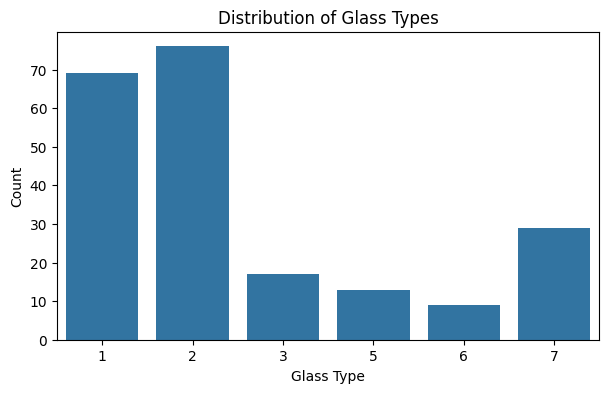

In [11]:
df["Type"].value_counts()

plt.figure(figsize=(7,4))
sns.countplot(x="Type", data=df)
plt.title("Distribution of Glass Types")
plt.xlabel("Glass Type")
plt.ylabel("Count")
plt.show()

Explanation

This step checks how many records are available for each glass type.
From the graph, we can understand whether the dataset is balanced or imbalanced.
If some classes have very low records compared to others, then the dataset is imbalanced.

# **Data Visualization**

**Histograms**

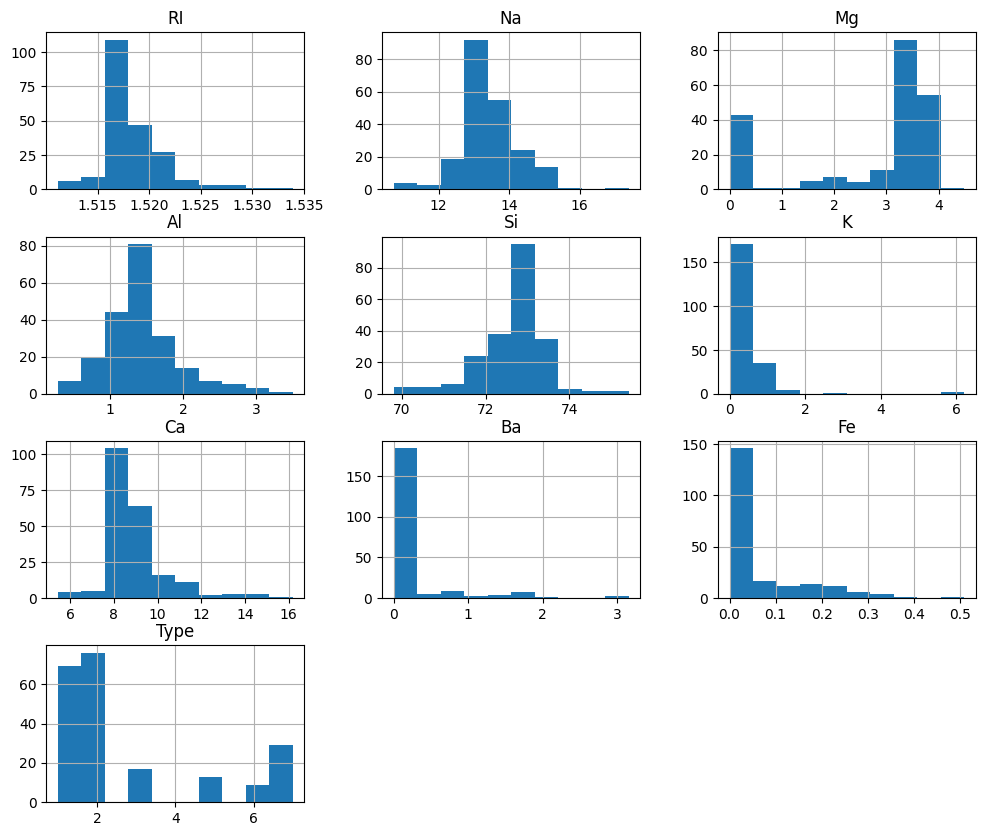

In [12]:
df.hist(figsize=(12,10))
plt.show()

Explanation

Histograms show the distribution of each numerical feature.
They help us understand whether the data is normally distributed or skewed.

**Boxplots**

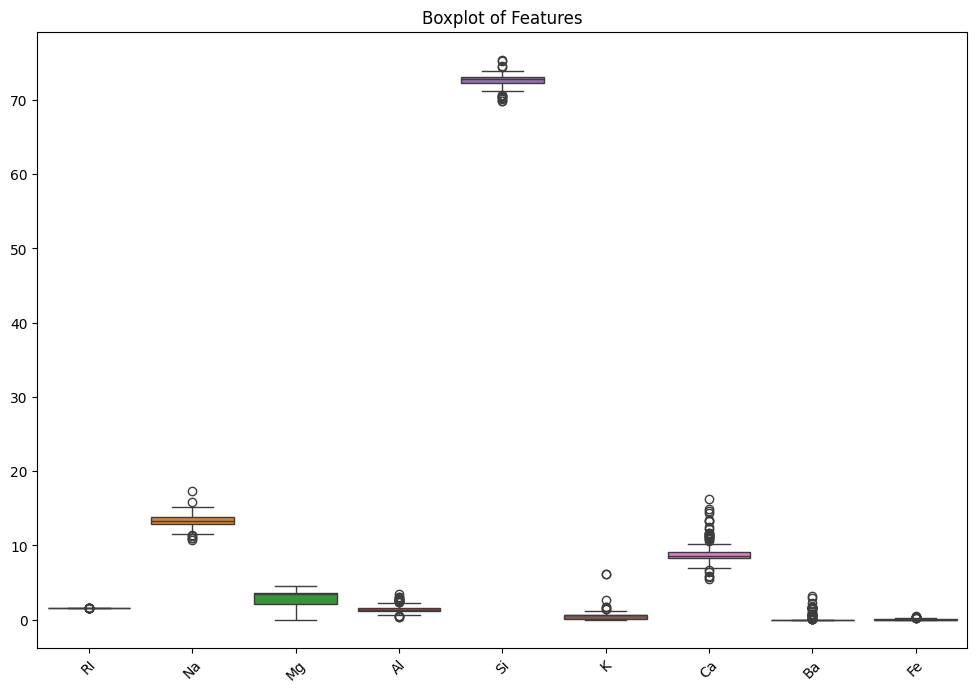

In [13]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop("Type", axis=1))
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

Explanation

Boxplots are used to detect outliers in numerical columns.
Some features may have extreme values, but Random Forest can handle outliers better than many other algorithms.

**Correlation Heatmap**

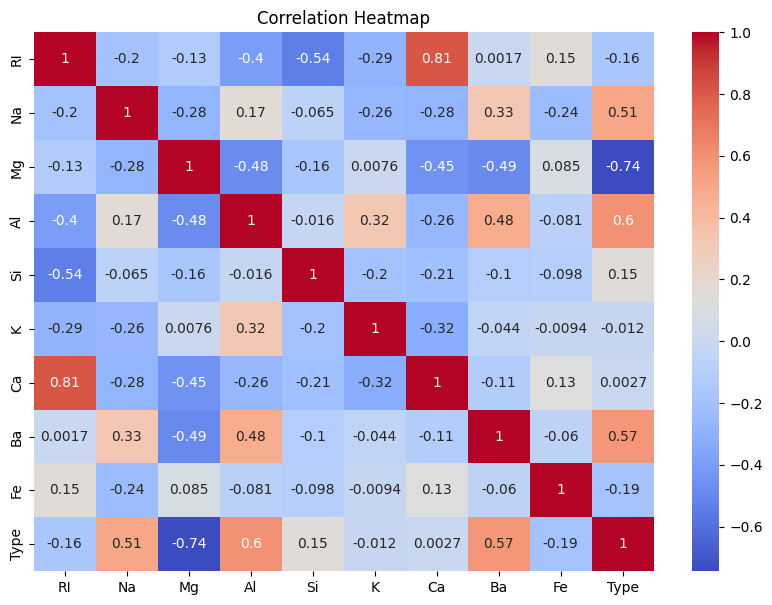

In [14]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Explanation

The heatmap shows the correlation between different features.
Correlation helps us understand which features are related to each other.

# **Separate Features and Target**

In [15]:
X = df.drop("Type", axis=1)
y = df["Type"]

Explanation

Here, X contains independent features such as RI, Na, Mg, Al, Si, K, Ca, Ba, and Fe.
The Type column is the target variable, so it is stored in y.

# **Train-Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

Explanation

The dataset is divided into training and testing data.
80% of the data is used for training and 20% is used for testing.
stratify=y is used because the target classes are imbalanced, and it keeps class distribution similar in train and test sets.

# **Feature Scaling**

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Explanation

Feature scaling is used to bring all numerical features to a similar scale.
Although Random Forest does not strictly need scaling, it is still applied here as part of preprocessing.

# **Random Forest Model**

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Explanation

Random Forest is an ensemble machine learning algorithm.
It builds multiple decision trees and combines their results to make better predictions.
Here, class_weight="balanced" is used to handle class imbalance.

# **Prediction Using Random Forest**

In [19]:
y_pred_rf = rf_model.predict(X_test_scaled)

Explanation

The trained Random Forest model is used to predict glass types on the test data.

# **Random Forest Model Evaluation**

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, average="weighted", zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, average="weighted", zero_division=0))

Accuracy: 0.8372093023255814
Precision: 0.8496124031007751
Recall: 0.8372093023255814
F1 Score: 0.8381570314208645


In [21]:
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.80      0.80      0.80        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.84        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.85      0.84      0.84        43



Explanation

Accuracy shows how many predictions are correct.
Precision shows how many predicted positive values are actually correct.
Recall shows how many actual values are correctly identified.
F1-score is the balance between precision and recall.

# **Confusion Matrix**

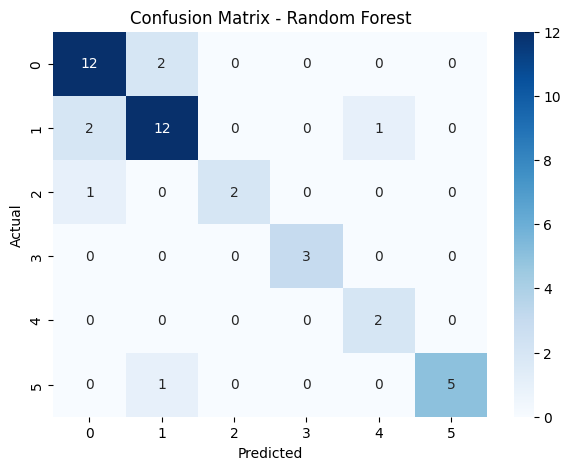

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Explanation

The confusion matrix shows correct and incorrect predictions for each class.
It helps us understand where the model is making mistakes.

# **Bagging Method**

In [23]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train_scaled, y_train)

y_pred_bagging = bagging_model.predict(X_test_scaled)

In [24]:
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Bagging Precision:", precision_score(y_test, y_pred_bagging, average="weighted", zero_division=0))
print("Bagging Recall:", recall_score(y_test, y_pred_bagging, average="weighted", zero_division=0))
print("Bagging F1 Score:", f1_score(y_test, y_pred_bagging, average="weighted", zero_division=0))

Bagging Accuracy: 0.7674418604651163
Bagging Precision: 0.7801771871539315
Bagging Recall: 0.7674418604651163
Bagging F1 Score: 0.7674272800174966


Explanation

Bagging means Bootstrap Aggregating.
It creates multiple models using different random samples of the training data.
The final prediction is made by combining the results of all models.
Bagging helps reduce overfitting and improves model stability.

# **Boosting Method**

**AdaBoost**

In [25]:
adaboost_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost_model.fit(X_train_scaled, y_train)

y_pred_adaboost = adaboost_model.predict(X_test_scaled)

In [26]:
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_adaboost))
print("AdaBoost Precision:", precision_score(y_test, y_pred_adaboost, average="weighted", zero_division=0))
print("AdaBoost Recall:", recall_score(y_test, y_pred_adaboost, average="weighted", zero_division=0))
print("AdaBoost F1 Score:", f1_score(y_test, y_pred_adaboost, average="weighted", zero_division=0))

AdaBoost Accuracy: 0.3953488372093023
AdaBoost Precision: 0.3852798364426271
AdaBoost Recall: 0.3953488372093023
AdaBoost F1 Score: 0.3857333020123717


Gradient **Boosting**

In [27]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

In [28]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Precision:", precision_score(y_test, y_pred_gb, average="weighted", zero_division=0))
print("Gradient Boosting Recall:", recall_score(y_test, y_pred_gb, average="weighted", zero_division=0))
print("Gradient Boosting F1 Score:", f1_score(y_test, y_pred_gb, average="weighted", zero_division=0))

Gradient Boosting Accuracy: 0.7906976744186046
Gradient Boosting Precision: 0.8040974529346623
Gradient Boosting Recall: 0.7906976744186046
Gradient Boosting F1 Score: 0.7865765892022457


Explanation

Boosting is an ensemble technique where models are trained one after another.
Each new model tries to correct the mistakes made by the previous model.
Boosting can improve accuracy, but sometimes it may overfit if not controlled properly.

# **Comparing All Models**

In [31]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "AdaBoost", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_adaboost),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_bagging, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_adaboost, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_gb, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_bagging, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_adaboost, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_gb, average="weighted", zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_bagging, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_adaboost, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_gb, average="weighted", zero_division=0)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.837209,0.849612,0.837209,0.838157
1,Bagging,0.767442,0.780177,0.767442,0.767427
2,AdaBoost,0.395349,0.385280,0.395349,0.385733
3,Gradient Boosting,0.790698,0.804097,0.790698,0.786577


# **Bar Plot for Model Comparison**

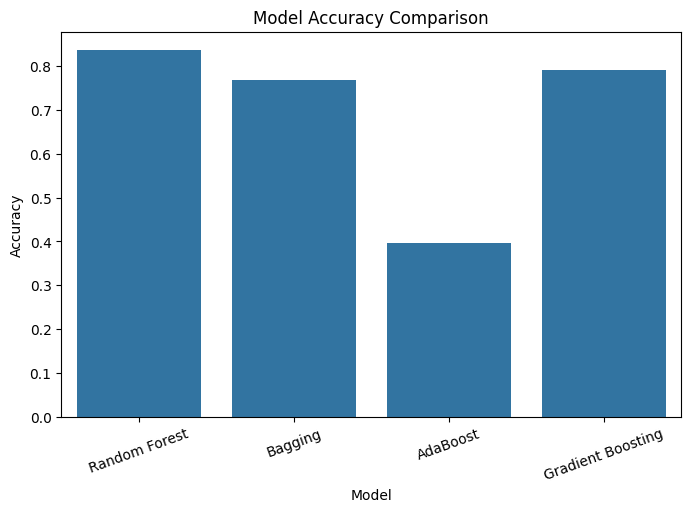

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

Explanation

This graph compares the accuracy of Random Forest, Bagging, AdaBoost, and Gradient Boosting.
The model with the highest accuracy performs better on the test data.

# **Difference Between Bagging and Boosting**

**Bagging**

Bagging trains multiple models independently.
Each model gets a different sample of the dataset.
The final result is taken by majority voting.
Random Forest is also based on the bagging concept.

**Boosting**

Boosting trains models one by one.
Each new model focuses more on the mistakes of the previous model.
Boosting can give high accuracy, but it may take more time and can overfit if the model becomes too complex.

**Main Difference**

Bagging trains models independently, while Boosting trains models sequentially.
Bagging mainly reduces overfitting, while Boosting mainly improves weak learners.

# **Handling Imbalanced Data**

The Glass dataset has unequal records for different glass types.
This means some classes have more samples and some classes have fewer samples.

**To handle imbalance, we can use:**

1. Stratified train-test split
2. class_weight="balanced"
3. Oversampling minority classes
4. Undersampling majority classes
5. Using proper metrics like precision, recall, and F1-score

# **Final Conclusion**

In this assignment, I used the Glass dataset for classification.
First, I performed exploratory data analysis and checked missing values, duplicates, class distribution, and feature relationships.
Then I applied feature scaling and split the dataset into training and testing sets.

After that, I trained a Random Forest Classifier and evaluated it using accuracy, precision, recall, and F1-score.
I also applied Bagging and Boosting methods and compared their results.

Random Forest performed well because it combines multiple decision trees and reduces overfitting.
Bagging also gave good results because it uses multiple models trained on different samples.
Boosting methods also performed well, especially Gradient Boosting, because they improve predictions step by step.

Overall, ensemble methods are useful for classification problems because they combine multiple models and generally give better performance than a single model.